Figure 2h,i — ELDA (statmod::elda χ² and pairwise p are printed with each curve)


Overall: Chi²=27.13, p=1.28e-06
  Root vs T1: p=5.46e-07
  Root vs T2: p=9.56e-04
  T1 vs T2: p=0.0051


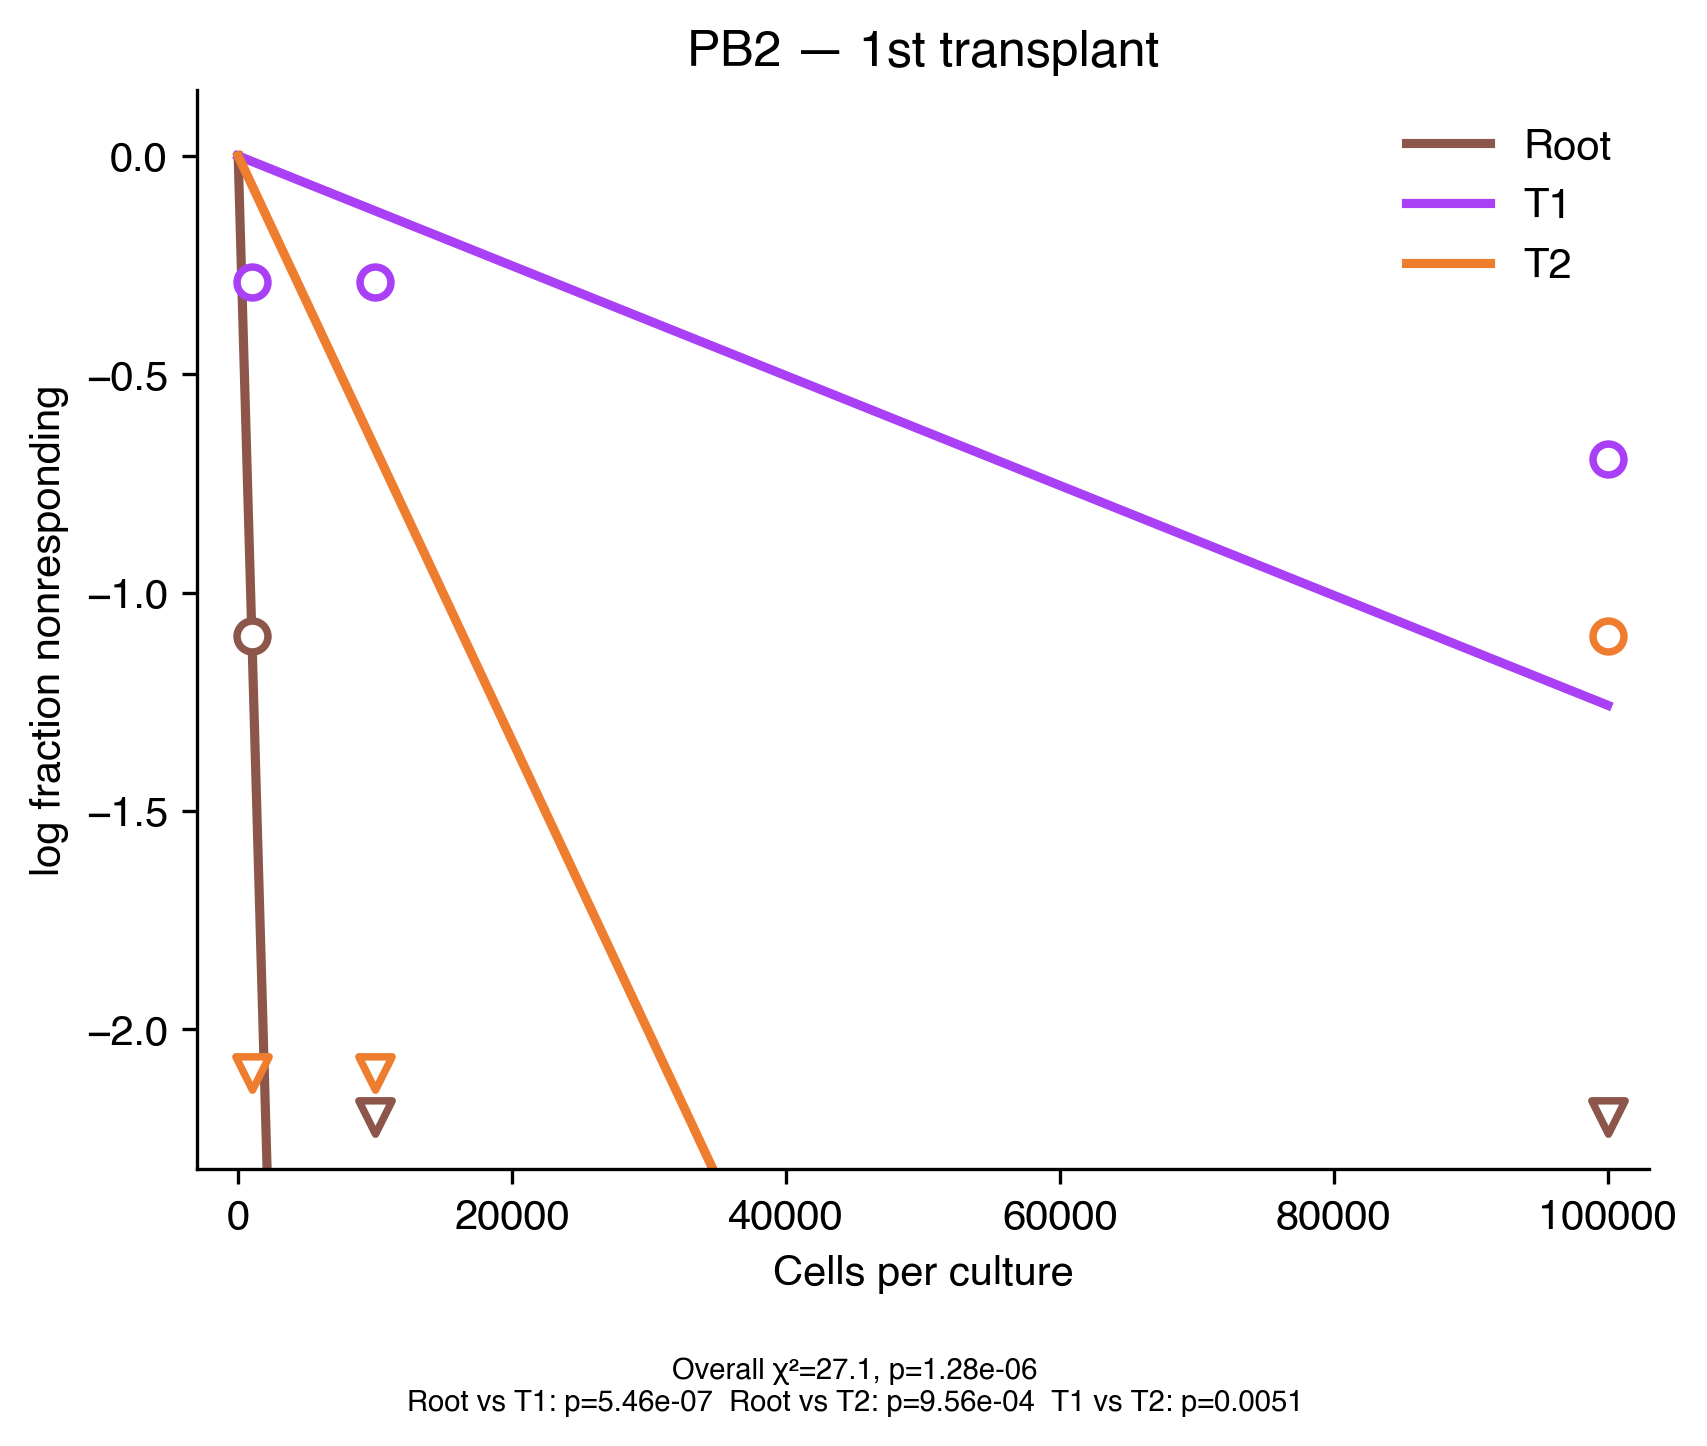

Saved → PATH_TO_FIGURES/ELDA_Plots/PB2-1st-transplant_elda.png


In [15]:
# ============ EDIT HERE ============
DATA = """\
Dose	Tested	Response	Group
1000	3	2	Root
10000	4	4	Root
100000	4	4	Root
1000	4	1	T1
10000	4	1	T1
100000	4	2	T1
1000	4	4	T2
10000	4	4	T2
100000	3	2	T2
"""

TITLE = "PB2 — 1st transplant"
COLORS = {
    "Root": (140/255, 86/255, 75/255),
    "T1":   (170/255, 64/255, 246/255),
    "T2":   (238/255, 125/255, 48/255),
}
GROUP_ORDER = ["Root", "T1", "T2"]
OUT = "PATH_TO_FIGURES/ELDA_Plots/PB2-1st-transplant_elda.png"
Y_FLOOR = -2.2
FLOOR_STEP = 0.05   # small vertical offset if triangles overlap (x unchanged)
# ===================================

import json, os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from io import StringIO

plt.rcParams.update({"font.family": "Helvetica", "font.size": 10})
df = pd.read_csv(StringIO(DATA), sep=r"\s+")

R_CODE = r'''
if (!requireNamespace("jsonlite", quietly=TRUE))
  install.packages("jsonlite", repos="https://cloud.r-project.org")
library(statmod); library(jsonlite)
d <- read.csv(textConnection(Sys.getenv("ELDA_DATA")), sep="\t")
d$Dose<-as.numeric(d$Dose); d$Tested<-as.numeric(d$Tested); d$Response<-as.numeric(d$Response)
fit <- elda(d$Response, d$Dose, d$Tested, group=d$Group, confidence=0.95)
ci <- fit$CI; overall <- fit$test.difference
pairs <- list(c("Root","T1"), c("Root","T2"), c("T1","T2"))
pw <- lapply(pairs, function(p) {
  sub <- d[d$Group %in% p, ]; sub$Group <- factor(sub$Group)
  f <- elda(sub$Response, sub$Dose, sub$Tested, group=sub$Group)
  list(g1=p[1], g2=p[2], chisq=unname(f$test.difference["Chisq"]),
       p=unname(f$test.difference["P.value"]))
})
cat(toJSON(list(
  ci=data.frame(Group=rownames(ci), Lower=ci[,1], Estimate=ci[,2], Upper=ci[,3]),
  overall=list(chisq=unname(overall["Chisq"]), df=unname(overall["df"]),
                 p=unname(overall["P.value"])), pairwise=pw
), auto_unbox=TRUE, digits=10))
'''

proc = subprocess.run(
    ["Rscript", "-e", R_CODE],
    capture_output=True, text=True,
    env={**os.environ, "ELDA_DATA": df.to_csv(sep="\t", index=False)},
)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr)
stats = json.loads(proc.stdout)
stats["ci"] = pd.DataFrame(stats["ci"])

def fit_freq(dose, tested, response):
    def nll(f):
        if f <= 0: return 1e30
        p = np.clip(1 - np.exp(-dose/f), 1e-12, 1-1e-12)
        return -np.sum(response*np.log(p)+(tested-response)*np.log(1-p))
    return minimize_scalar(nll, bounds=(1,1e7), method="bounded").x

def point_y(t, r, group_idx):
    if r >= t:
        return Y_FLOOR + group_idx * FLOOR_STEP
    if r <= 0:
        return 0.0
    return np.log((t-r)/t)

def fmt_p(p):
    return f"{p:.2e}" if p < 0.001 else f"{p:.4f}"

print("="*60)
o = stats["overall"]
print(f"Overall: Chi²={o['chisq']:.2f}, p={fmt_p(o['p'])}")
for pw in stats["pairwise"]:
    print(f"  {pw['g1']} vs {pw['g2']}: p={fmt_p(pw['p'])}")
print("="*60)

xmax = df.Dose.max()
pad = xmax * 0.03
fig, ax = plt.subplots(figsize=(5.8, 4.8), dpi=300)
x = np.linspace(0, xmax, 200)

for gi, g in enumerate(GROUP_ORDER):
    sub = df[df.Group == g]
    dose, tested, resp = sub.Dose.values, sub.Tested.values, sub.Response.values
    c = COLORS[g]
    freq = fit_freq(dose, tested, resp)
    ax.plot(x, -x/freq, color=c, lw=2.2, label=g, zorder=2)

    for d, t, r in zip(dose, tested, resp):
        y = point_y(t, r, gi)
        mk = "v" if r >= t else "o"
        ax.scatter(d, y, s=64 if mk=="v" else 55, facecolors="white",
                   edgecolors=c, linewidths=1.8, marker=mk, zorder=3, clip_on=False)

ax.set_xlim(-pad, xmax+pad)
ax.set_ylim(Y_FLOOR-0.12, 0.15)
ax.set_title(TITLE, fontweight="bold")
ax.set_xlabel("Cells per culture")
ax.set_ylabel("log fraction nonresponding")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top","right"]].set_visible(False)

note = f"Overall χ²={o['chisq']:.1f}, p={fmt_p(o['p'])}\n" + "  ".join(
    f"{p['g1']} vs {p['g2']}: p={fmt_p(p['p'])}" for p in stats["pairwise"])
fig.text(0.5, 0.01, note, ha="center", fontsize=7)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT}")


  Root: 1 in 1 (1 in 1,558 – 1 in 1)
  T2: not reached (upper bound 1 in 14,688)

Overall: Chi²=30.82, p=2.83e-08
  Root vs T2: p=2.83e-08


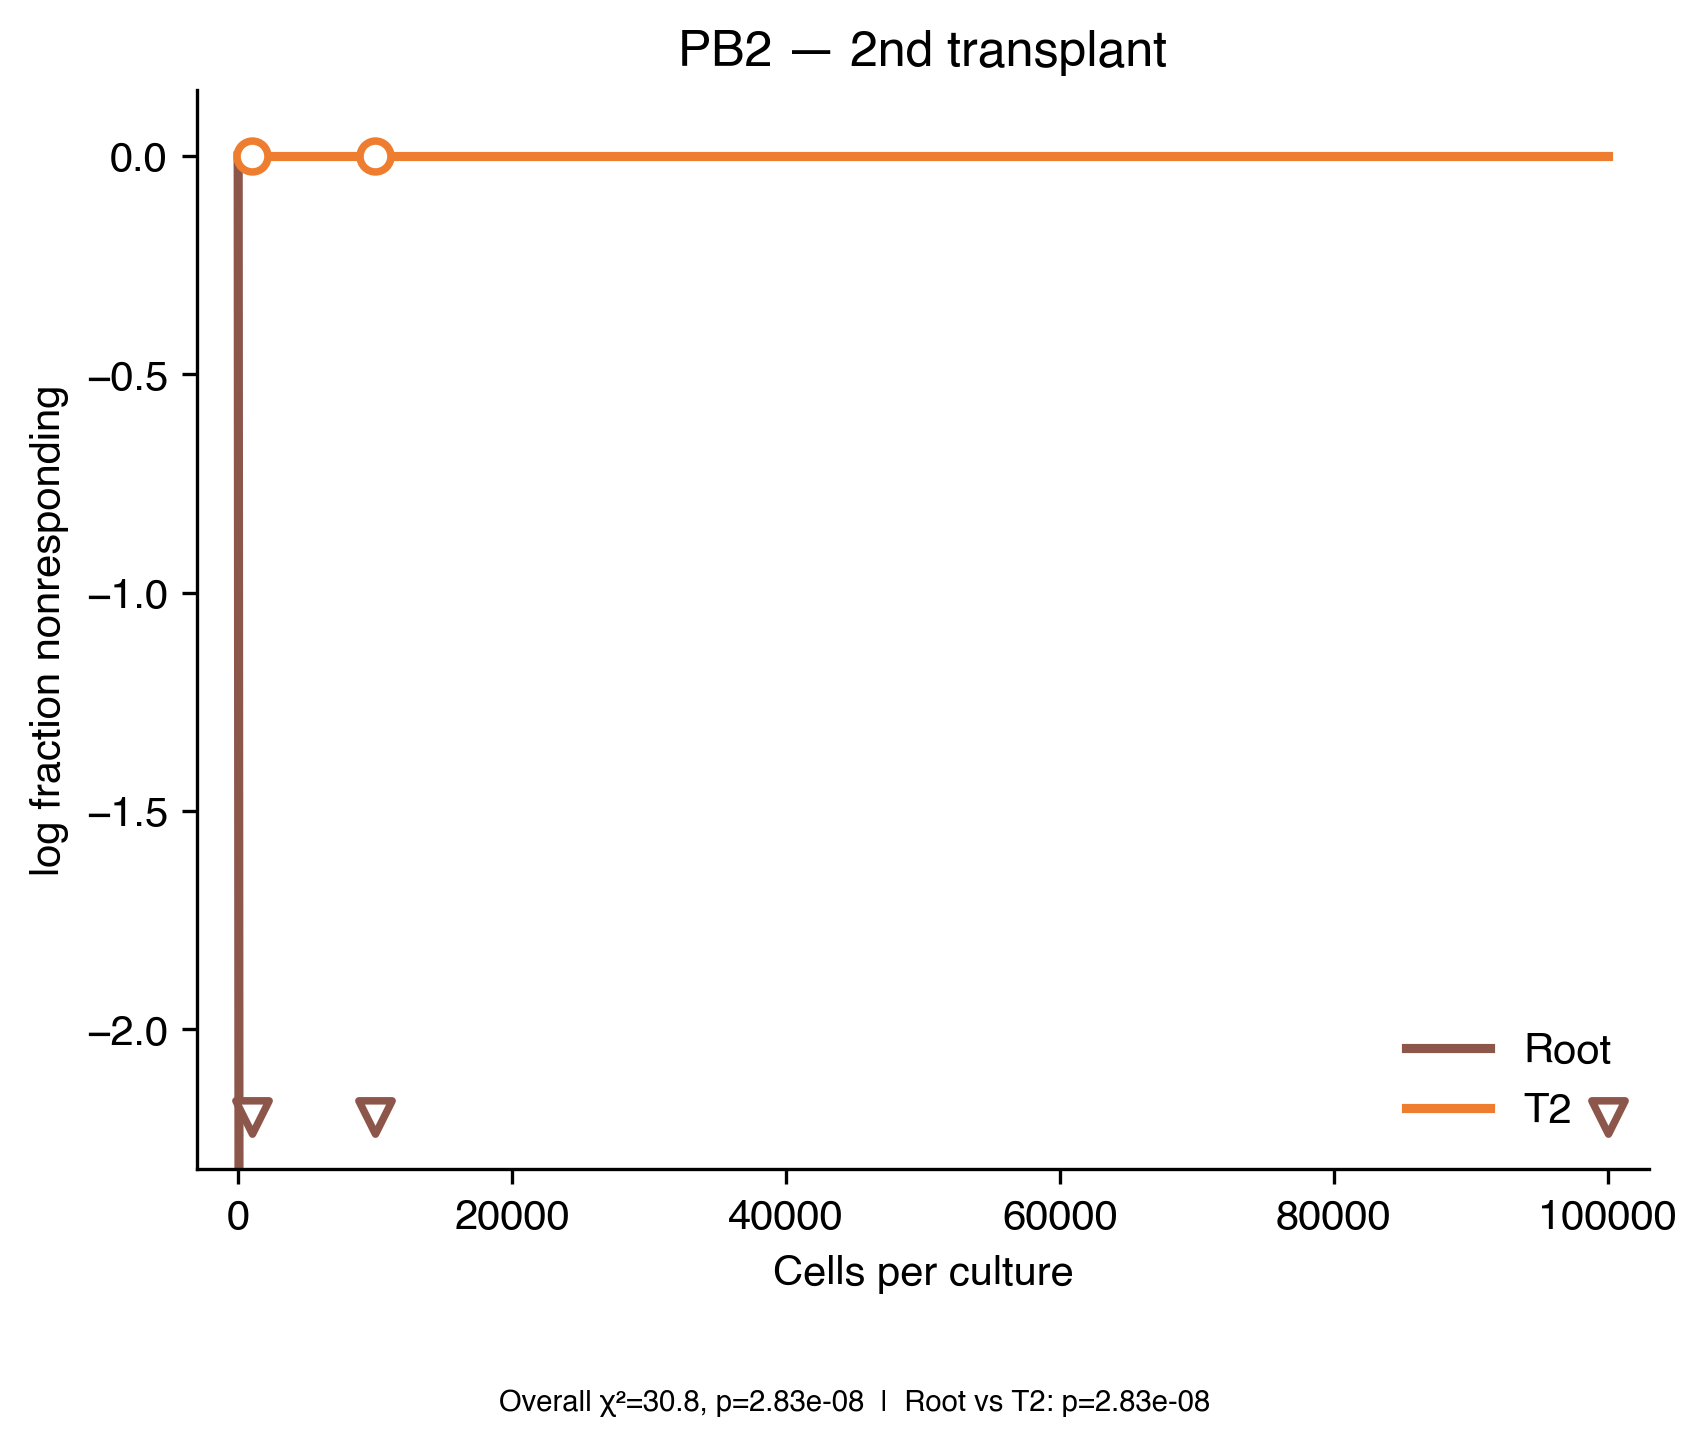

Saved → PATH_TO_FIGURES/ELDA_Plots/PB2-2nd-transplant_elda.png


In [22]:
# ============ EDIT HERE ============
DATA = """\
Dose	Tested	Response	Group
1000	4	4	Root
10000	4	4	Root
100000	4	4	Root
1000	4	0	T2
10000	4	0	T2
"""

TITLE = "PB2 — 2nd transplant"
COLORS = {
    "Root": (140/255, 86/255, 75/255),
    "T2":   (238/255, 125/255, 48/255),
}
GROUP_ORDER = ["Root", "T2"]
OUT = "PATH_TO_FIGURES/ELDA_Plots/PB2-2nd-transplant_elda.png"
Y_FLOOR = -2.2
FLOOR_STEP = 0.05
# ===================================

import json, os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from io import StringIO

plt.rcParams.update({"font.family": "Helvetica", "font.size": 10})
df = pd.read_csv(StringIO(DATA), sep=r"\s+")

R_CODE = r'''
if (!requireNamespace("jsonlite", quietly=TRUE))
  install.packages("jsonlite", repos="https://cloud.r-project.org")
library(statmod); library(jsonlite)
d <- read.csv(textConnection(Sys.getenv("ELDA_DATA")), sep="\t")
d$Dose<-as.numeric(d$Dose); d$Tested<-as.numeric(d$Tested); d$Response<-as.numeric(d$Response)
fit <- elda(d$Response, d$Dose, d$Tested, group=d$Group, confidence=0.95)
ci <- fit$CI; overall <- fit$test.difference
pairs <- list(c("Root","T2"))
pw <- lapply(pairs, function(p) {
  sub <- d[d$Group %in% p, ]; sub$Group <- factor(sub$Group)
  f <- elda(sub$Response, sub$Dose, sub$Tested, group=sub$Group)
  list(g1=p[1], g2=p[2], chisq=unname(f$test.difference["Chisq"]),
       p=unname(f$test.difference["P.value"]))
})
cat(toJSON(list(
  ci=data.frame(Group=rownames(ci), Lower=ci[,1], Estimate=ci[,2], Upper=ci[,3]),
  overall=list(chisq=unname(overall["Chisq"]), df=unname(overall["df"]),
                 p=unname(overall["P.value"])), pairwise=pw
), auto_unbox=TRUE, digits=10))
'''

proc = subprocess.run(
    ["Rscript", "-e", R_CODE],
    capture_output=True, text=True,
    env={**os.environ, "ELDA_DATA": df.to_csv(sep="\t", index=False)},
)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr)
stats = json.loads(proc.stdout)
stats["ci"] = pd.DataFrame(stats["ci"])

def fit_freq(dose, tested, response):
    dose = np.asarray(dose, float)
    tested = np.asarray(tested, float)
    response = np.asarray(response, float)
    if response.sum() == 0:
        return np.inf
    def nll(f):
        if f <= 0: return 1e30
        p = np.clip(1 - np.exp(-dose / f), 1e-12, 1 - 1e-12)
        return -np.sum(response * np.log(p) + (tested - response) * np.log(1 - p))
    return minimize_scalar(nll, bounds=(1, 1e7), method="bounded").x

def point_y(t, r, group_idx):
    if r >= t:
        return Y_FLOOR + group_idx * FLOOR_STEP
    if r <= 0:
        return 0.0
    return np.log((t - r) / t)

def fmt_p(p):
    return f"{p:.2e}" if p < 0.001 else f"{p:.4f}"

print("=" * 60)
for _, row in stats["ci"].iterrows():
    g = row.Group.replace("Group ", "")
    if not np.isfinite(row.Estimate) or row.Estimate > 1e5:
        print(f"  {g}: not reached (upper bound 1 in {row.Upper:,.0f})")
    else:
        print(f"  {g}: 1 in {row.Estimate:.0f} (1 in {row.Lower:,.0f} – 1 in {row.Upper:.0f})")
o = stats["overall"]
print(f"\nOverall: Chi²={o['chisq']:.2f}, p={fmt_p(o['p'])}")
for pw in stats["pairwise"]:
    print(f"  {pw['g1']} vs {pw['g2']}: p={fmt_p(pw['p'])}")
print("=" * 60)

xmax = df.Dose.max()
pad = xmax * 0.03
fig, ax = plt.subplots(figsize=(5.8, 4.8), dpi=300)
x = np.linspace(0, xmax, 200)

for gi, g in enumerate(GROUP_ORDER):
    sub = df[df.Group == g]
    dose, tested, resp = sub.Dose.values, sub.Tested.values, sub.Response.values
    c = COLORS[g]
    freq = fit_freq(dose, tested, resp)
    if np.isinf(freq):
        ax.plot(x, np.zeros_like(x), color=c, lw=2.2, label=g, zorder=2)
    else:
        ax.plot(x, -x / freq, color=c, lw=2.2, label=g, zorder=2)

    for d, t, r in zip(dose, tested, resp):
        y = point_y(t, r, gi)
        mk = "v" if r >= t else "o"
        ax.scatter(d, y, s=64 if mk == "v" else 55, facecolors="white",
                   edgecolors=c, linewidths=1.8, marker=mk, zorder=3, clip_on=False)

ax.set_xlim(-pad, xmax + pad)
ax.set_ylim(Y_FLOOR - 0.12, 0.15)
ax.set_title(TITLE, fontweight="bold")
ax.set_xlabel("Cells per culture")
ax.set_ylabel("log fraction nonresponding")
ax.legend(frameon=False, loc="lower right")   # ← fix: was upper right
ax.spines[["top", "right"]].set_visible(False)

note = f"Overall χ²={o['chisq']:.1f}, p={fmt_p(o['p'])}  |  " + "  ".join(
    f"{p['g1']} vs {p['g2']}: p={fmt_p(p['p'])}" for p in stats["pairwise"])
fig.text(0.5, 0.01, note, ha="center", fontsize=7)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT}")


  Root: 1 in 1 (1 in 1,486 – 1 in 1)
  T1: 1 in 714 (1 in 2,331 – 1 in 219)

Overall: Chi²=1.52, p=0.2172
  Root vs T1: p=0.2172


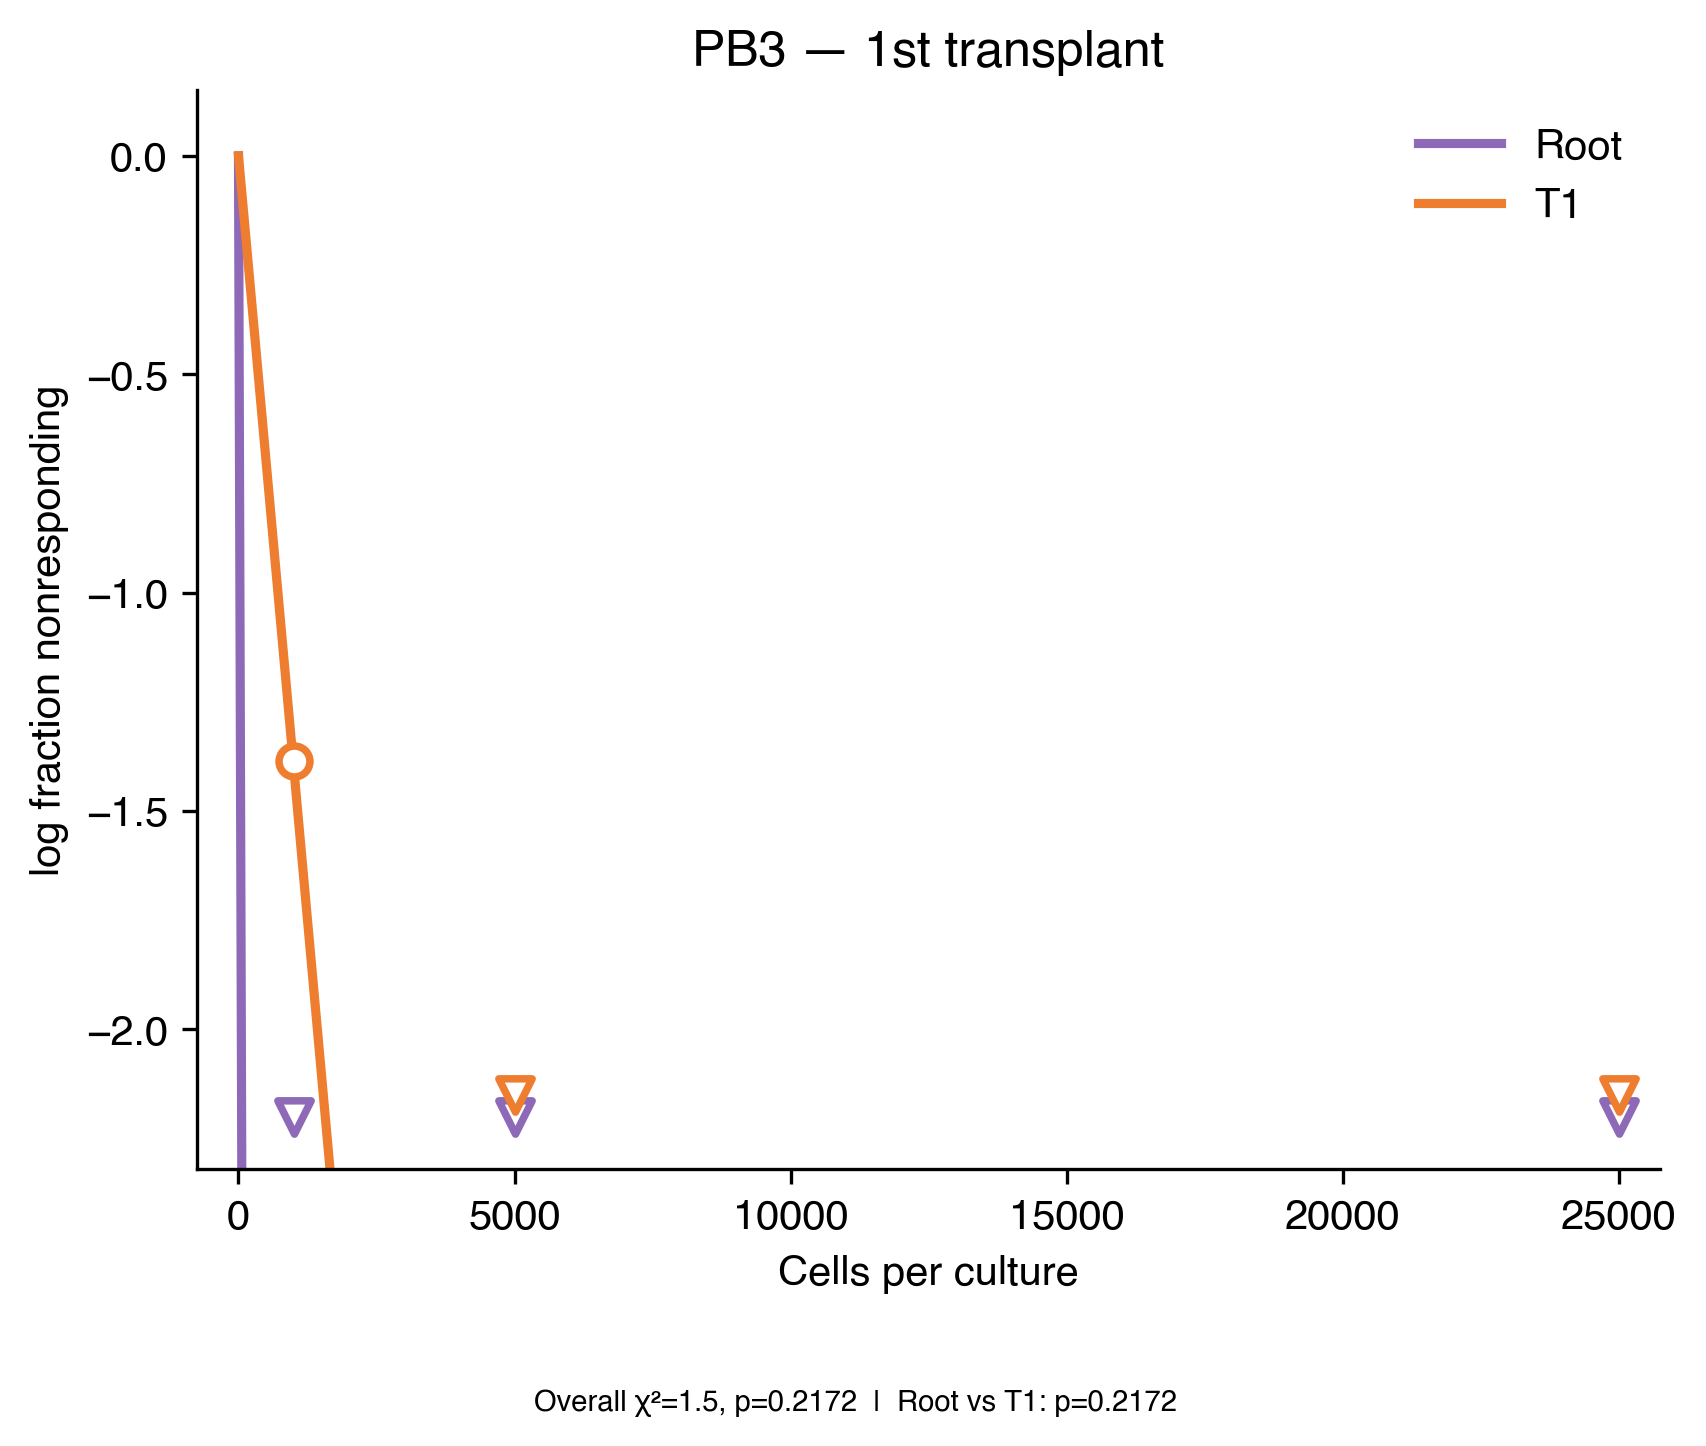

Saved → PATH_TO_FIGURES/ELDA_Plots/PB3-1st-transplant_elda.png


In [12]:
# ============ EDIT HERE ============
DATA = """\
Dose	Tested	Response	Group
1000	4	4	Root
5000	4	4	Root
25000	4	4	Root
1000	4	3	T1
5000	4	4	T1
25000	4	4	T1
"""

TITLE = "PB3 — 1st transplant"
COLORS = {
    "Root": (141/255, 105/255, 184/255),   # #B2182B
    "T1":   (238/255, 125/255, 48/255),  # #2166AC
}
GROUP_ORDER = ["Root", "T1"]
OUT = "PATH_TO_FIGURES/ELDA_Plots/PB3-1st-transplant_elda.png"
Y_FLOOR = -2.2
FLOOR_STEP = 0.05
# ===================================

import json, os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from io import StringIO

plt.rcParams.update({"font.family": "Helvetica", "font.size": 10})
df = pd.read_csv(StringIO(DATA), sep=r"\s+")

R_CODE = r'''
if (!requireNamespace("jsonlite", quietly=TRUE))
  install.packages("jsonlite", repos="https://cloud.r-project.org")
library(statmod); library(jsonlite)
d <- read.csv(textConnection(Sys.getenv("ELDA_DATA")), sep="\t")
d$Dose<-as.numeric(d$Dose); d$Tested<-as.numeric(d$Tested); d$Response<-as.numeric(d$Response)
fit <- elda(d$Response, d$Dose, d$Tested, group=d$Group, confidence=0.95)
ci <- fit$CI; overall <- fit$test.difference
pairs <- list(c("Root","T1"))
pw <- lapply(pairs, function(p) {
  sub <- d[d$Group %in% p, ]; sub$Group <- factor(sub$Group)
  f <- elda(sub$Response, sub$Dose, sub$Tested, group=sub$Group)
  list(g1=p[1], g2=p[2], chisq=unname(f$test.difference["Chisq"]),
       p=unname(f$test.difference["P.value"]))
})
cat(toJSON(list(
  ci=data.frame(Group=rownames(ci), Lower=ci[,1], Estimate=ci[,2], Upper=ci[,3]),
  overall=list(chisq=unname(overall["Chisq"]), df=unname(overall["df"]),
                 p=unname(overall["P.value"])), pairwise=pw
), auto_unbox=TRUE, digits=10))
'''

proc = subprocess.run(
    ["Rscript", "-e", R_CODE],
    capture_output=True, text=True,
    env={**os.environ, "ELDA_DATA": df.to_csv(sep="\t", index=False)},
)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr)
stats = json.loads(proc.stdout)
stats["ci"] = pd.DataFrame(stats["ci"])

def fit_freq(dose, tested, response):
    dose = np.asarray(dose, float)
    tested = np.asarray(tested, float)
    response = np.asarray(response, float)
    if response.sum() == 0:
        return np.inf
    def nll(f):
        if f <= 0:
            return 1e30
        p = np.clip(1 - np.exp(-dose / f), 1e-12, 1 - 1e-12)
        return -np.sum(response * np.log(p) + (tested - response) * np.log(1 - p))
    return minimize_scalar(nll, bounds=(1, 1e7), method="bounded").x

def point_y(t, r, group_idx):
    if r >= t:
        return Y_FLOOR + group_idx * FLOOR_STEP
    if r <= 0:
        return 0.0
    return np.log((t - r) / t)

def fmt_p(p):
    return f"{p:.2e}" if p < 0.001 else f"{p:.4f}"

print("=" * 60)
for _, row in stats["ci"].iterrows():
    g = row.Group.replace("Group ", "")
    if row.Estimate < 10:
        print(f"  {g}: 1 in {row.Estimate:.0f} (1 in {row.Lower:,.0f} – 1 in {row.Upper:.0f})")
    else:
        print(f"  {g}: 1 in {row.Estimate:,.0f} (1 in {row.Lower:,.0f} – 1 in {row.Upper:,.0f})")
o = stats["overall"]
print(f"\nOverall: Chi²={o['chisq']:.2f}, p={fmt_p(o['p'])}")
for pw in stats["pairwise"]:
    print(f"  {pw['g1']} vs {pw['g2']}: p={fmt_p(pw['p'])}")
print("=" * 60)

xmax = df.Dose.max()
pad = xmax * 0.03
fig, ax = plt.subplots(figsize=(5.8, 4.8), dpi=300)
x = np.linspace(0, xmax, 200)

for gi, g in enumerate(GROUP_ORDER):
    sub = df[df.Group == g]
    dose, tested, resp = sub.Dose.values, sub.Tested.values, sub.Response.values
    c = COLORS[g]
    freq = fit_freq(dose, tested, resp)
    ax.plot(x, -x / freq, color=c, lw=2.2, label=g, zorder=2)

    for d, t, r in zip(dose, tested, resp):
        y = point_y(t, r, gi)
        mk = "v" if r >= t else "o"
        ax.scatter(d, y, s=64 if mk == "v" else 55, facecolors="white",
                   edgecolors=c, linewidths=1.8, marker=mk, zorder=3, clip_on=False)

ax.set_xlim(-pad, xmax + pad)
ax.set_ylim(Y_FLOOR - 0.12, 0.15)
ax.set_title(TITLE, fontweight="bold")
ax.set_xlabel("Cells per culture")
ax.set_ylabel("log fraction nonresponding")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

note = f"Overall χ²={o['chisq']:.1f}, p={fmt_p(o['p'])}  |  " + "  ".join(
    f"{p['g1']} vs {p['g2']}: p={fmt_p(p['p'])}" for p in stats["pairwise"])
fig.text(0.5, 0.01, note, ha="center", fontsize=7)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT}")


  Root: 1 in 1 (1 in 1,486 – 1 in 1)
  T1: 1 in 7,983 (1 in 24,534 – 1 in 2,597)

Overall: Chi²=17.38, p=3.06e-05
  Root vs T1: p=3.06e-05


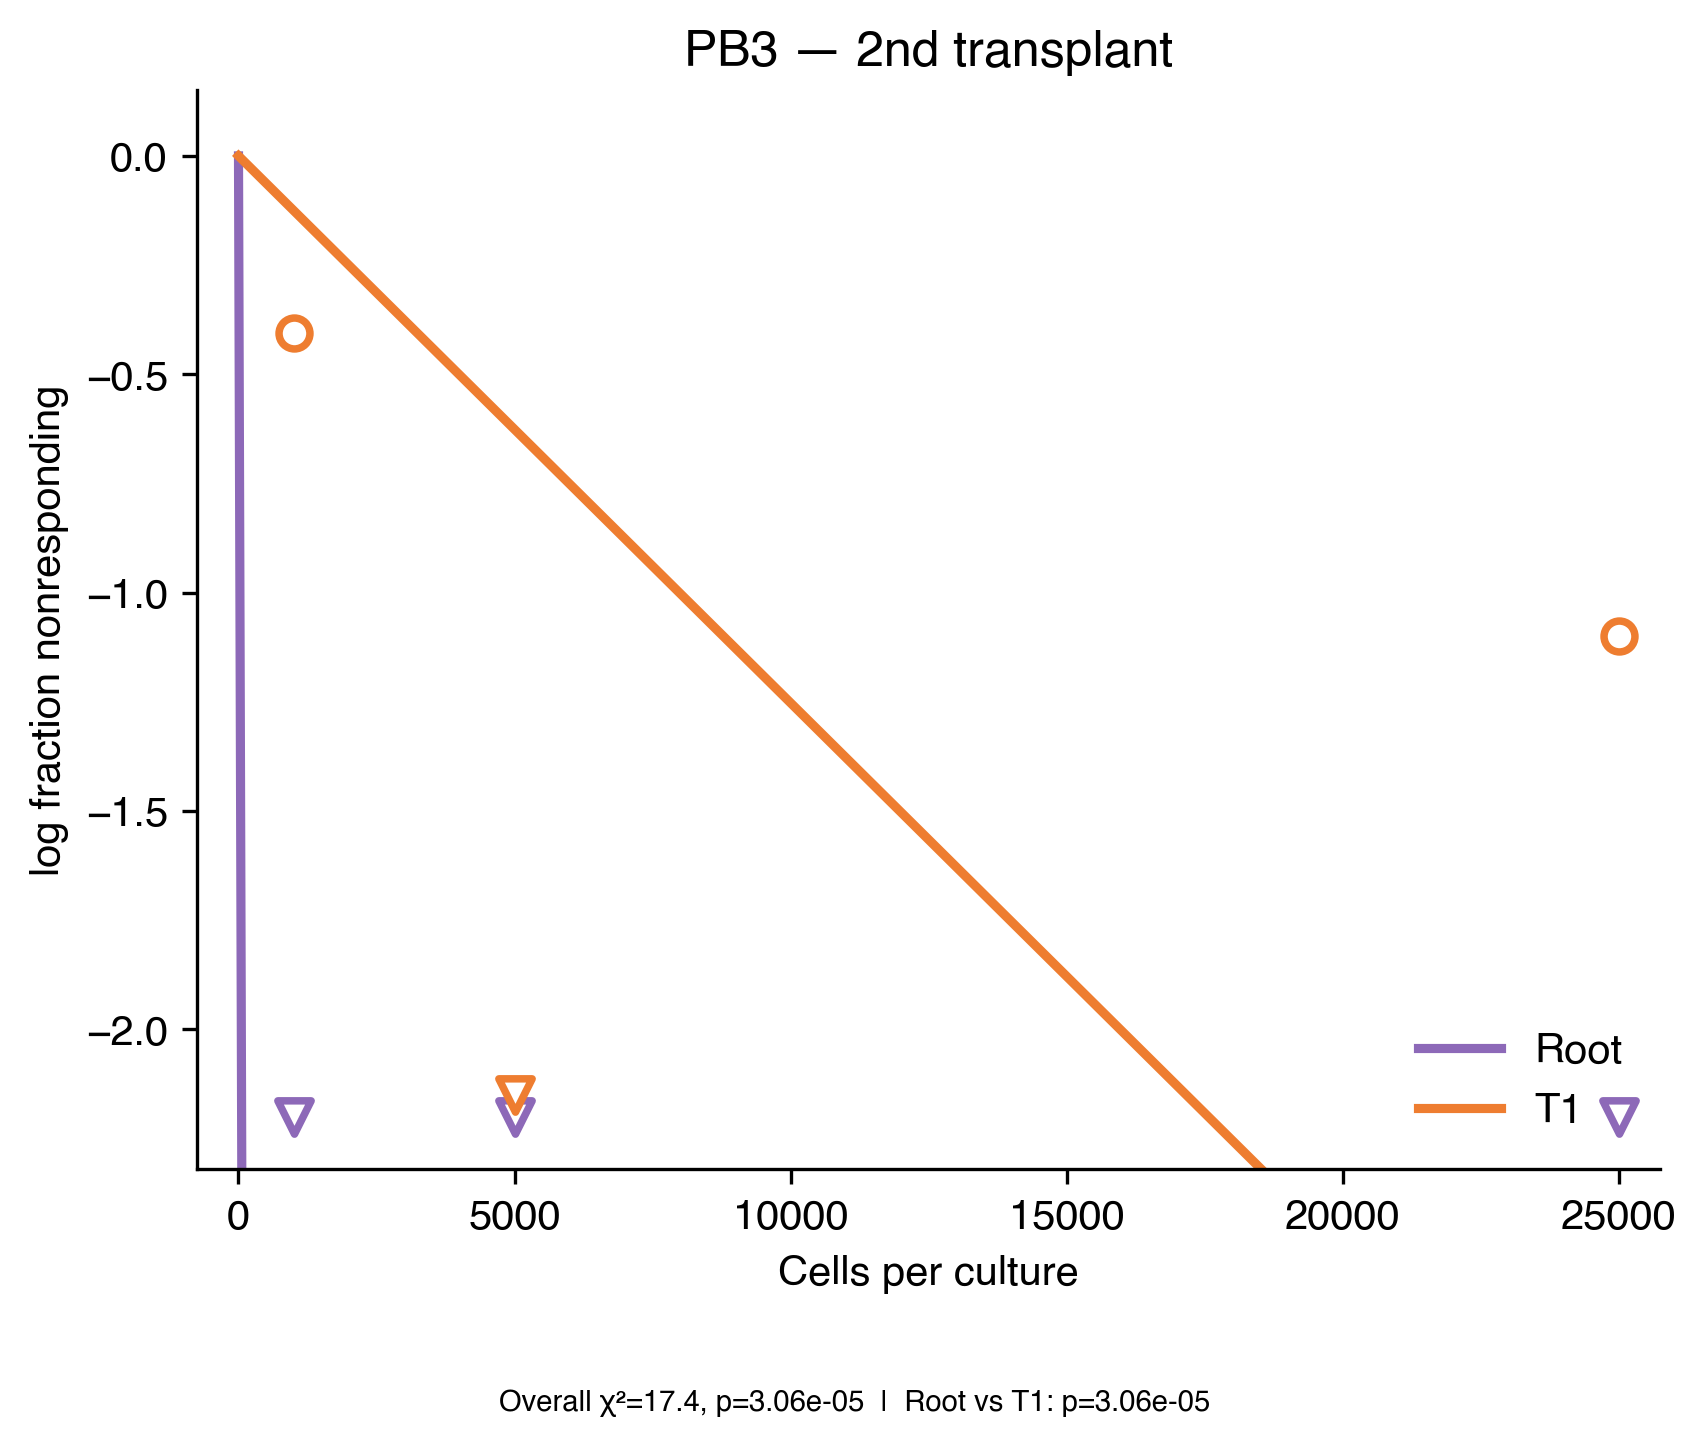

Saved → PATH_TO_FIGURES/ELDA_Plots/PB3-2nd-transplant_elda.png


In [11]:
# ============ EDIT HERE ============
DATA = """\
Dose	Tested	Response	Group
1000	4	4	Root
5000	4	4	Root
25000	4	4	Root
1000	3	1	T1
5000	3	3	T1
25000	3	2	T1
"""

TITLE = "PB3 — 2nd transplant"
COLORS = {
    "Root": (141/255, 105/255, 184/255),   # #B2182B
    "T1":   (238/255, 125/255, 48/255),  # #2166AC
}
GROUP_ORDER = ["Root", "T1"]
OUT = "PATH_TO_FIGURES/ELDA_Plots/PB3-2nd-transplant_elda.png"
Y_FLOOR = -2.2
FLOOR_STEP = 0.05
# ===================================

import json, os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from io import StringIO

plt.rcParams.update({"font.family": "Helvetica", "font.size": 10})
df = pd.read_csv(StringIO(DATA), sep=r"\s+")

R_CODE = r'''
if (!requireNamespace("jsonlite", quietly=TRUE))
  install.packages("jsonlite", repos="https://cloud.r-project.org")
library(statmod); library(jsonlite)
d <- read.csv(textConnection(Sys.getenv("ELDA_DATA")), sep="\t")
d$Dose<-as.numeric(d$Dose); d$Tested<-as.numeric(d$Tested); d$Response<-as.numeric(d$Response)
fit <- elda(d$Response, d$Dose, d$Tested, group=d$Group, confidence=0.95)
ci <- fit$CI; overall <- fit$test.difference
pairs <- list(c("Root","T1"))
pw <- lapply(pairs, function(p) {
  sub <- d[d$Group %in% p, ]; sub$Group <- factor(sub$Group)
  f <- elda(sub$Response, sub$Dose, sub$Tested, group=sub$Group)
  list(g1=p[1], g2=p[2], chisq=unname(f$test.difference["Chisq"]),
       p=unname(f$test.difference["P.value"]))
})
cat(toJSON(list(
  ci=data.frame(Group=rownames(ci), Lower=ci[,1], Estimate=ci[,2], Upper=ci[,3]),
  overall=list(chisq=unname(overall["Chisq"]), df=unname(overall["df"]),
                 p=unname(overall["P.value"])), pairwise=pw
), auto_unbox=TRUE, digits=10))
'''

proc = subprocess.run(
    ["Rscript", "-e", R_CODE],
    capture_output=True, text=True,
    env={**os.environ, "ELDA_DATA": df.to_csv(sep="\t", index=False)},
)
if proc.returncode != 0:
    raise RuntimeError(proc.stderr)
stats = json.loads(proc.stdout)
stats["ci"] = pd.DataFrame(stats["ci"])

def fit_freq(dose, tested, response):
    dose = np.asarray(dose, float)
    tested = np.asarray(tested, float)
    response = np.asarray(response, float)
    if response.sum() == 0:
        return np.inf
    def nll(f):
        if f <= 0:
            return 1e30
        p = np.clip(1 - np.exp(-dose / f), 1e-12, 1 - 1e-12)
        return -np.sum(response * np.log(p) + (tested - response) * np.log(1 - p))
    return minimize_scalar(nll, bounds=(1, 1e7), method="bounded").x

def point_y(t, r, group_idx):
    if r >= t:
        return Y_FLOOR + group_idx * FLOOR_STEP
    if r <= 0:
        return 0.0
    return np.log((t - r) / t)

def fmt_p(p):
    return f"{p:.2e}" if p < 0.001 else f"{p:.4f}"

print("=" * 60)
for _, row in stats["ci"].iterrows():
    g = row.Group.replace("Group ", "")
    if row.Estimate < 10:
        print(f"  {g}: 1 in {row.Estimate:.0f} (1 in {row.Lower:,.0f} – 1 in {row.Upper:.0f})")
    else:
        print(f"  {g}: 1 in {row.Estimate:,.0f} (1 in {row.Lower:,.0f} – 1 in {row.Upper:,.0f})")
o = stats["overall"]
print(f"\nOverall: Chi²={o['chisq']:.2f}, p={fmt_p(o['p'])}")
for pw in stats["pairwise"]:
    print(f"  {pw['g1']} vs {pw['g2']}: p={fmt_p(pw['p'])}")
print("=" * 60)

xmax = df.Dose.max()
pad = xmax * 0.03
fig, ax = plt.subplots(figsize=(5.8, 4.8), dpi=300)
x = np.linspace(0, xmax, 200)

for gi, g in enumerate(GROUP_ORDER):
    sub = df[df.Group == g]
    dose, tested, resp = sub.Dose.values, sub.Tested.values, sub.Response.values
    c = COLORS[g]
    freq = fit_freq(dose, tested, resp)
    ax.plot(x, -x / freq, color=c, lw=2.2, label=g, zorder=2)

    for d, t, r in zip(dose, tested, resp):
        y = point_y(t, r, gi)
        mk = "v" if r >= t else "o"
        ax.scatter(d, y, s=64 if mk == "v" else 55, facecolors="white",
                   edgecolors=c, linewidths=1.8, marker=mk, zorder=3, clip_on=False)

ax.set_xlim(-pad, xmax + pad)
ax.set_ylim(Y_FLOOR - 0.12, 0.15)
ax.set_title(TITLE, fontweight="bold")
ax.set_xlabel("Cells per culture")
ax.set_ylabel("log fraction nonresponding")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

note = f"Overall χ²={o['chisq']:.1f}, p={fmt_p(o['p'])}  |  " + "  ".join(
    f"{p['g1']} vs {p['g2']}: p={fmt_p(p['p'])}" for p in stats["pairwise"])
fig.text(0.5, 0.01, note, ha="center", fontsize=7)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT}")
